# Here the comes the Selective classifiers


In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

import pickle

In [2]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [3]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [4]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = 'adult48k'
dt_name = "german_credit"
dt_name = "toy_dataset"
cf_method = 'lore'#dice or 'debug'
cf_latent = False


name_dataset = {"german_credit": "German Credit", 
                "adult48k": "Adult",
                "toy_dataset":"Toy Dataset",
                }[dt_name]
name_dataset_command = {"German Credit": "\\german",
                        "Adult": "\\adult48",
                        "Two Moons":"\\twomoons",
                        }
cf_results

'counterfactuals/'

In [5]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/toy_dataset/feature_names.csv
Loaded X_train from data/processed/toy_dataset/X_train.npz
Loaded y_train from data/processed/toy_dataset/y_train.npz
Loaded X_test from data/processed/toy_dataset/X_test.npz
Loaded y_test from data/processed/toy_dataset/y_test.npz
Loaded X_calibration from data/processed/toy_dataset/X_calibration.npz
Loaded y_calibration from data/processed/toy_dataset/y_calibration.npz


In [6]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for toy_dataset
Loaded random_forest model from models/toy_dataset/random_forest.pkl
Loaded existing random_forest model
Processing mlp for toy_dataset
Loaded mlp model from models/toy_dataset/mlp.pkl
Loaded existing mlp model
Processing xgboost for toy_dataset
Loaded xgboost model from models/toy_dataset/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for toy_dataset
Loaded lgbm model from models/toy_dataset/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [7]:
from selective_classifiers import load_distance_stats,check_res,convert_lists_to_arrays,initialize_rejectors,calibrate_basic_rejectors,calibrate_distance_rejectors,evaluate_rejectors,create_dataframes


## Load the distances files

In [8]:
fname = os.path.join(cf_method,dt_name+"_ranking_latent.pkl")
fname_test = os.path.join(cf_method,dt_name+"_ranking_test_latent.pkl")



# Load distance statistics
all_stats, all_stats_test = load_distance_stats(cf_method, dt_name, cf_latent)



Loaded lore/toy_dataset_ranking.pkl
Loaded lore/toy_dataset_ranking_test.pkl


In [9]:
# Check if distances are computed
for k in models.keys():
    print(k, "computed?", check_res(stats_dict=all_stats, k=k))
    print("\t", "test?", check_res(stats_dict=all_stats_test, k=k))

(200 elements computed)
random_forest computed? True
(250 elements computed)
	 test? True
(200 elements computed)
mlp computed? True
(250 elements computed)
	 test? True
(200 elements computed)
xgboost computed? True
(250 elements computed)
	 test? True
(200 elements computed)
lgbm computed? True
(250 elements computed)
	 test? True


In [10]:
all_stats = convert_lists_to_arrays(models, all_stats)
all_stats_test = convert_lists_to_arrays(models, all_stats_test)

In [11]:
name_dataset_command

{'German Credit': '\\german', 'Adult': '\\adult48', 'Two Moons': '\\twomoons'}

#### Here we import the necessary libraries for the 
# Selective classifiers


In [12]:

#from Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss

from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
# use importlib as we have to reload the module
#importlib.reload(cfdr)
import rejectmodels.CFDistRejector as cfdr

from src.utils import compute_selective_metrics



In [13]:
import rejectmodels.CFTreeRejector as cftree
importlib.reload(cftree)

<module 'rejectmodels.CFTreeRejector' from '/home/vbonsignori/L2loRe/rejectmodels/CFTreeRejector.py'>

In [14]:
focus_metrics = ["inf",
 'chebyshev',
 'l2',
 'minkowski',
 'wasserstein',
 'l1',
 'mae',
 'sqeuclidean']
#focus_metrics = ['l2']

In [15]:
rejectors, metric_dicts, info = initialize_rejectors(models, splits)

In [16]:
# Calibrate basic rejectors
rejectors = calibrate_basic_rejectors(models, rejectors, splits, all_stats, all_stats_test, info)

Calibrating basic rejectors: 100%|██████████| 4/4 [00:00<00:00, 27.53it/s]

Calibrating basic rejectors for model random_forest
Basic rejectors calibrated:
PlugInRule: [32 17 12 17 32]
PlugInRuleAUC: [18. 22.  6. 12. 18.]
Calibrating basic rejectors for model mlp
Basic rejectors calibrated:
PlugInRule: [22 28 14 21 19]
PlugInRuleAUC: [18. 31. 12. 16. 14.]
Calibrating basic rejectors for model xgboost
Basic rejectors calibrated:
PlugInRule: [32 14 32  9 32]
PlugInRuleAUC: [17. 16. 17.  5. 17.]
Calibrating basic rejectors for model lgbm
Basic rejectors calibrated:
PlugInRule: [27 17 22  6 23]
PlugInRuleAUC: [21. 21. 12.  1. 13.]


In [17]:
rejectors = calibrate_distance_rejectors(models, rejectors, splits, all_stats, all_stats_test, info)

Calibrating distance-based rejectors: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


In [18]:
# Evaluate all rejectors
metric_dicts = evaluate_rejectors(models, rejectors, splits, metric_dicts, info)


Evaluating rejectors: 100%|██████████| 4/4 [00:46<00:00, 11.71s/it]


In [19]:
all_original_scores = info['all_original_scores']

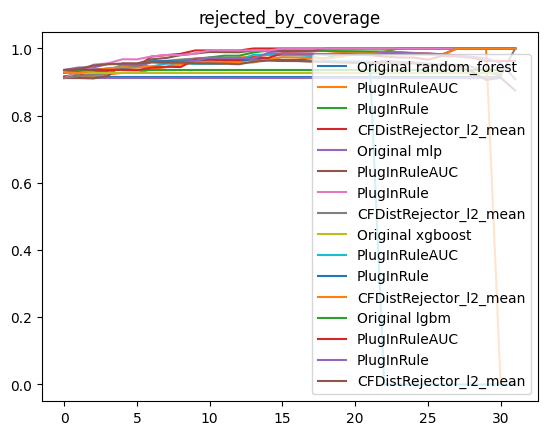

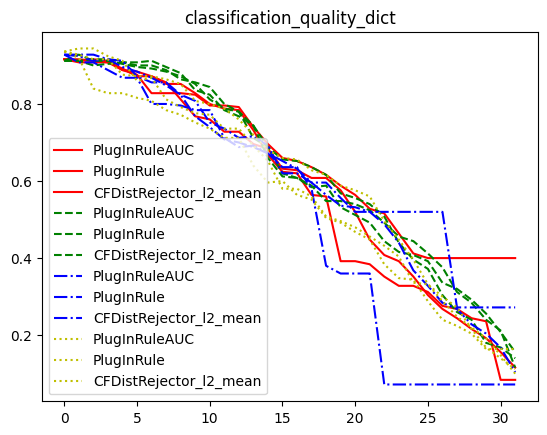

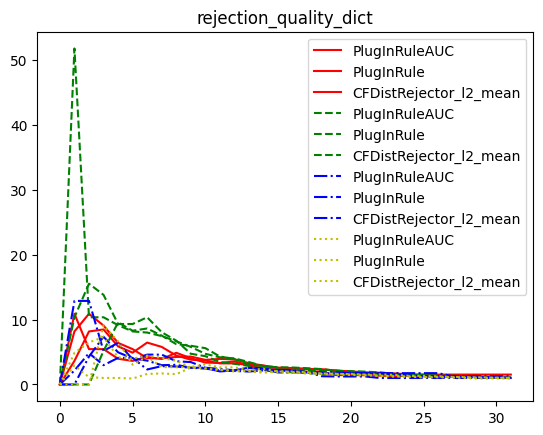

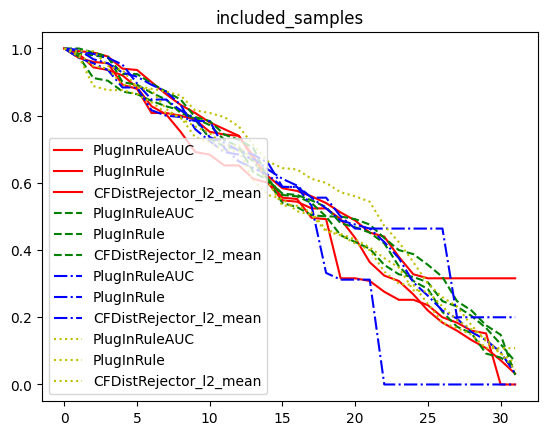

In [20]:
for m in metric_dicts.keys():
    if m=="rejected_by_coverage":
        # place horizontal line at the original bb score
        for k in models.keys():
            plt.plot([0,30],[all_original_scores[k],all_original_scores[k]],label="Original "+k)
        
            plt.plot(metric_dicts[m][k]["PlugInRuleAUC"],label="PlugInRuleAUC")
            plt.plot(metric_dicts[m][k]["PlugInRule"],label="PlugInRule")
            plt.plot(metric_dicts[m][k]["CFDistRejector_l2_mean"],label="CFDistRejector_l2_mean")
    else:
        for k in models.keys():
            model_idx = {k1:i for i,k1 in enumerate(models.keys())}[k]
            ls = ["-","--","-.",":"][model_idx]
            color = ["r","g","b","y"][model_idx]
            plt.plot(metric_dicts[m][k]["PlugInRuleAUC"],label="PlugInRuleAUC",ls=ls,color=color)
            plt.plot(metric_dicts[m][k]["PlugInRule"],label="PlugInRule",ls=ls,color=color)
            plt.plot(metric_dicts[m][k]["CFDistRejector_l2_mean"],label="CFDistRejector_l2_mean",ls=ls,color=color)
    plt.legend()
    plt.title(m)
    plt.show()


In [21]:
# Create dataframes for visualization
dataframes = create_dataframes(models, metric_dicts, info)

In [22]:
from src.data_processor import fancy_dataset_names


In [23]:
# clean the entries 
if cf_method == "ils":
    if cf_latent:
        cf_method = "ils<latent"
for km in dataframes.keys():
    # remove the name CFDistRejector from the indexes and replace it by the cf_method
    dataframes[km].index = [(f"{cf_method}_{col}" if col not in ["PlugInRule", "PlugInRuleAUC"] else col) for col in dataframes[km].index]
'''for km in dataframes.keys():
    if km not in dataframes.keys():
        all_dataframes[km] = dataframes[km]
    else:
        # drop the raws relatively to the PlugInRule and PlugInRuleAUC
        dataframes[km] = dataframes[km].drop(["PlugInRule", "PlugInRuleAUC"], axis=0)
        all_dataframes[km] = pd.concat([all_dataframes[km], dataframes[km]], axis=0)'''

'for km in dataframes.keys():\n    if km not in dataframes.keys():\n        all_dataframes[km] = dataframes[km]\n    else:\n        # drop the raws relatively to the PlugInRule and PlugInRuleAUC\n        dataframes[km] = dataframes[km].drop(["PlugInRule", "PlugInRuleAUC"], axis=0)\n        all_dataframes[km] = pd.concat([all_dataframes[km], dataframes[km]], axis=0)'

# Same but Step by Step

In [24]:
top_k  = 8

vmax 1.007
minimum 0.905


In [34]:
from selective_classifiers import generate_latex_table, plot_line_graph_nb, fancy_names, create_legend_file, simplified_plot_styling


In [ ]:
import matplotlib.colors as mcolors


: 

In [53]:
def plot_line_graph_nb2(ax, df, top_policies, top_policies_names, 
                    target_coverages, all_original_scores, 
                    model_name, minimumm, vmaxx,
                    selective,# the name of the selective metric
                    indx=0):
    """Plot line graph of top methods."""
    for j, policy_idx in enumerate(top_policies):
        if policy_idx == 0:  # PlugInRule
            ls = '--'
            marker = 'd'
        elif policy_idx == 1:  # PlugInRuleAUC
            ls = '--'
            marker = 's'
        else:
            ls = '-'
            marker = 'o'

        label = top_policies_names[j]
        style = simplified_plot_styling(label)
        ax.plot(df.columns, df.values[policy_idx, :], 
                label=label, 
                ls=style['ls'],
                marker=style['marker'],
                color=style['color'],
                linewidth=style['linewidth'],
                markersize=style['markersize'],
                )

    ax.axhline(all_original_scores[model_name], label=f"Original {model_name}", color='k', ls='--')
    # only the target coverages that are multiples of 0.05 plus the 0.99
    target_coverages = target_coverages.copy()
    target_coverages = np.array(target_coverages)[((np.array(target_coverages)*100)%5==0)]
    target_coverages = np.concatenate([[0.99], target_coverages])
    
    ax.set_xticks(target_coverages)
    ax.set_xticklabels([f"{e*100:.0f}%" for e in target_coverages], rotation=0,
                       fontsize=18)
    xlims = ax.get_xlim()
    ax.set_xlim(xlims[1], xlims[0])
    ax.set_xlabel("Target Coverage"   , fontsize=20)
    # ax.legend()
    if minimumm is not None and vmaxx is not None:
        print(minimumm, vmaxx)
        ax.set_ylim(minimumm, vmaxx)
    else:
        ax.set_ylim(0, 1)
    if indx == 0:
        if selective == "rejected_by_coverage":
            ylab = "Non-rejected Accuracy"
        elif selective == "rejection_quality_dict":
            ylab = "Rejection Quality"
        elif selective == "classification_quality_dict":
            ylab = "Classification Quality"
        ax.set_ylabel(ylab, fontsize=20)
    if indx == 3:
        # place the yticklabels on the right
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        #ax.set_yticks(ax.get_yticks()[::2])
        
        ax.set_yticklabels([f"{e*100:.1f}%" for e in ax.get_yticks()], fontsize=18)
    else:
        ax.set_yticklabels(["" for e in ax.get_yticks()], fontsize=18)
        
    ax.grid(True,alpha=0.6)

In [54]:
#fancy_names_old = fancy_names
def fancy_names(name):
    """Return a cooler name for the selective classifier"""
    if name == "PlugInRule":
        return "PlugInRule"
    elif name == "PlugInRuleAUC":
        return "PlugInRuleAUC"
    else:
        """Return a cooler name for the selective classifier"""
        if name.endswith("duplicate"):
            duplicate_flag = " (D)"
            name = name.replace("_duplicate", "")
        else:
            duplicate_flag = ""
        distr = name.split("_")[-1]
        if distr == "gamma":
            apex = "^{\gamma}"
            name = name.replace("_gamma", "")
        else:
            apex = ""
        if name.split("_")[1] == "CFDistRejector":
            tree = ""
        elif name.split("_")[1] == "CFTreeRejector":
            tree = " (Tree)"
        distr = name.split("_")[-1]
        if distr == "mean":
            distr = "_{mean}"
        elif distr == "min":
            distr = "_{min}"
        elif distr == "max":
            distr = "_{max}"
        method = name.split("_")[0]

        if method == "ils<latent":
            method = "ILS$_{latent}$"
        else:
            method = method.upper()
        distance = name.split("_")[2]
        
        newn= method+tree+" - "+distance+"$"+apex+distr+"$" #+ duplicate_flag
        # print(name,newn)
        return newn

vmax None
minimum None


Visualizing results:   0%|          | 0/4 [00:00<?, ?it/s]

top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_cosine_max_gamma', 'lore_CFDistRejector_sqeuclidean_min_gamma', 'lore_CFDistRejector_cosine_max', 'lore_CFDistRejector_l1_mean_gamma_duplicate', 'lore_CFDistRejector_l2_mean_gamma_duplicate', 'lore_CFDistRejector_l2_min_duplicate']
top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_sqeuclidean_mean_gamma', 'lore_CFDistRejector_sqeuclidean_min_gamma', 'lore_CFDistRejector_l1_mean_gamma_duplicate', 'lore_CFDistRejector_l1_mean_duplicate', 'lore_CFDistRejector_inf_mean_duplicate', 'lore_CFDistRejector_l2_mean_gamma_duplicate']
top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_l1_min_gamma_duplicate', 'lore_CFDistRejector_l2_min_gamma_duplicate', 'lore_CFDistRejector_inf_min_gamma_duplicate', 'lore_CFDistRejector_l1_min_duplicate', 'lore_CFDistRejector_wasserstein_min', 'lore_CFDistRejector_l2_min_duplicate']
top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', '

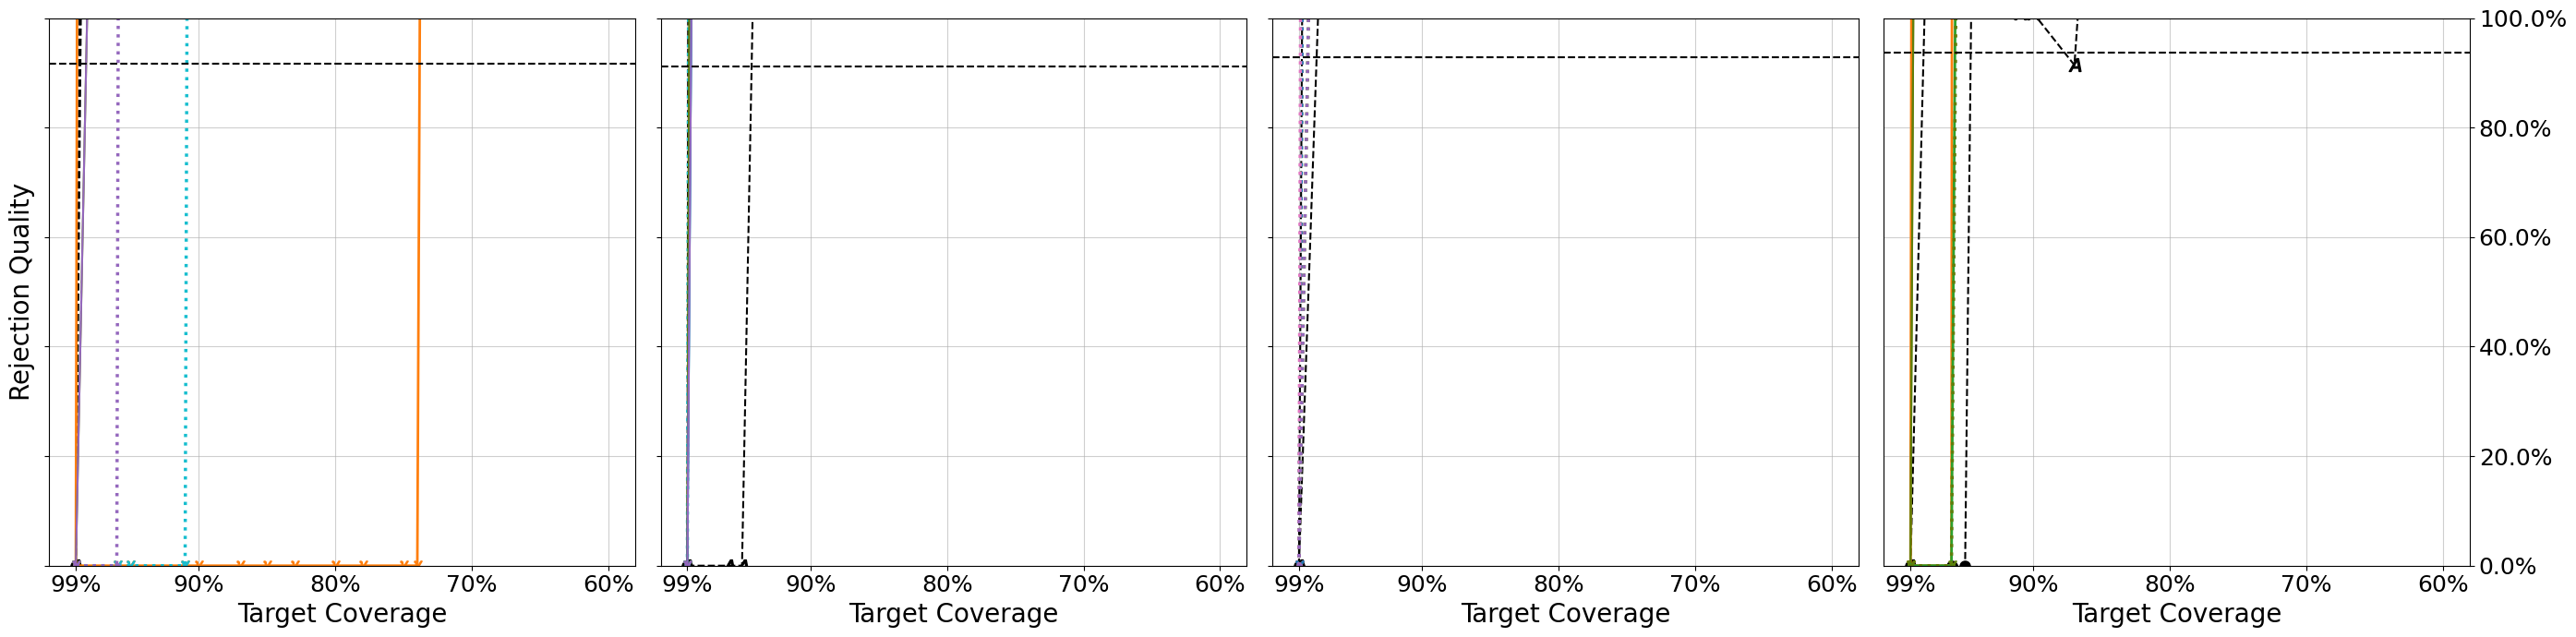

['PlugInRule', 'PlugInRuleAUC', 'LORE - cosine$^{\\gamma}_{max}$', 'LORE - sqeuclidean$^{\\gamma}_{min}$', 'LORE - cosine$_{max}$', 'LORE - l1$^{\\gamma}_{mean}$', 'LORE - l2$^{\\gamma}_{mean}$', 'LORE - l2$_{min}$', 'LORE - sqeuclidean$^{\\gamma}_{mean}$', 'LORE - sqeuclidean$^{\\gamma}_{min}$', 'LORE - l1$^{\\gamma}_{mean}$', 'LORE - l1$_{mean}$', 'LORE - inf$_{mean}$', 'LORE - l2$^{\\gamma}_{mean}$', 'LORE - l1$^{\\gamma}_{min}$', 'LORE - l2$^{\\gamma}_{min}$', 'LORE - inf$^{\\gamma}_{min}$', 'LORE - l1$_{min}$', 'LORE - wasserstein$_{min}$', 'LORE - l2$_{min}$', 'LORE - cosine$^{\\gamma}_{max}$', 'LORE - cosine$_{max}$', 'LORE - l1$^{\\gamma}_{mean}$', 'LORE - l1$_{mean}$', 'LORE - braycurtis$_{max}$', 'LORE - l1$^{\\gamma}_{min}$']


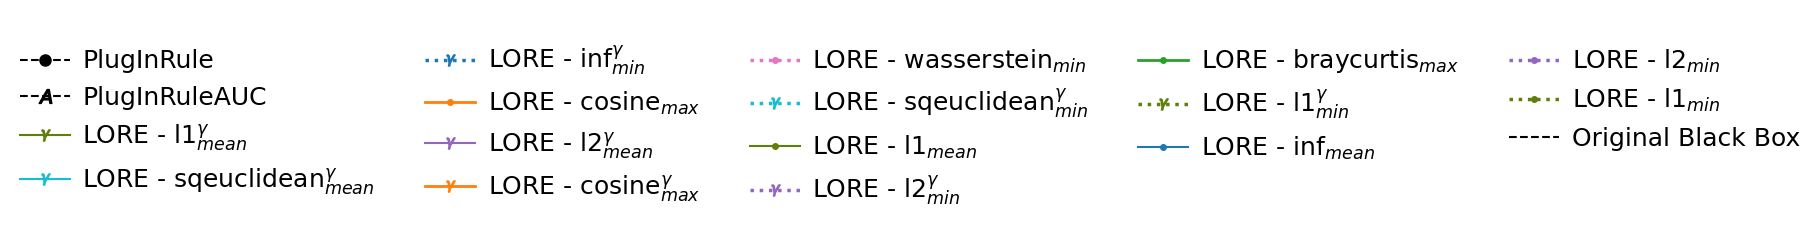

vmax None
minimum None


Visualizing results:   0%|          | 0/4 [00:00<?, ?it/s]

top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_cosine_max_gamma', 'lore_CFDistRejector_sqeuclidean_min_gamma', 'lore_CFDistRejector_braycurtis_max', 'lore_CFDistRejector_braycurtis_max_gamma', 'lore_CFDistRejector_inf_min_gamma_duplicate', 'lore_CFDistRejector_l2_min_gamma_duplicate']
top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_braycurtis_max_gamma', 'lore_CFDistRejector_sqeuclidean_mean_gamma', 'lore_CFDistRejector_cosine_max_gamma', 'lore_CFDistRejector_braycurtis_max', 'lore_CFDistRejector_l1_mean_gamma_duplicate', 'lore_CFDistRejector_l2_mean_gamma_duplicate']
top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_braycurtis_max_gamma', 'lore_CFDistRejector_braycurtis_max', 'lore_CFDistRejector_cosine_max_gamma', 'lore_CFDistRejector_l1_min_gamma_duplicate', 'lore_CFDistRejector_l2_min_gamma_duplicate', 'lore_CFDistRejector_inf_min_gamma_duplicate']
top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC

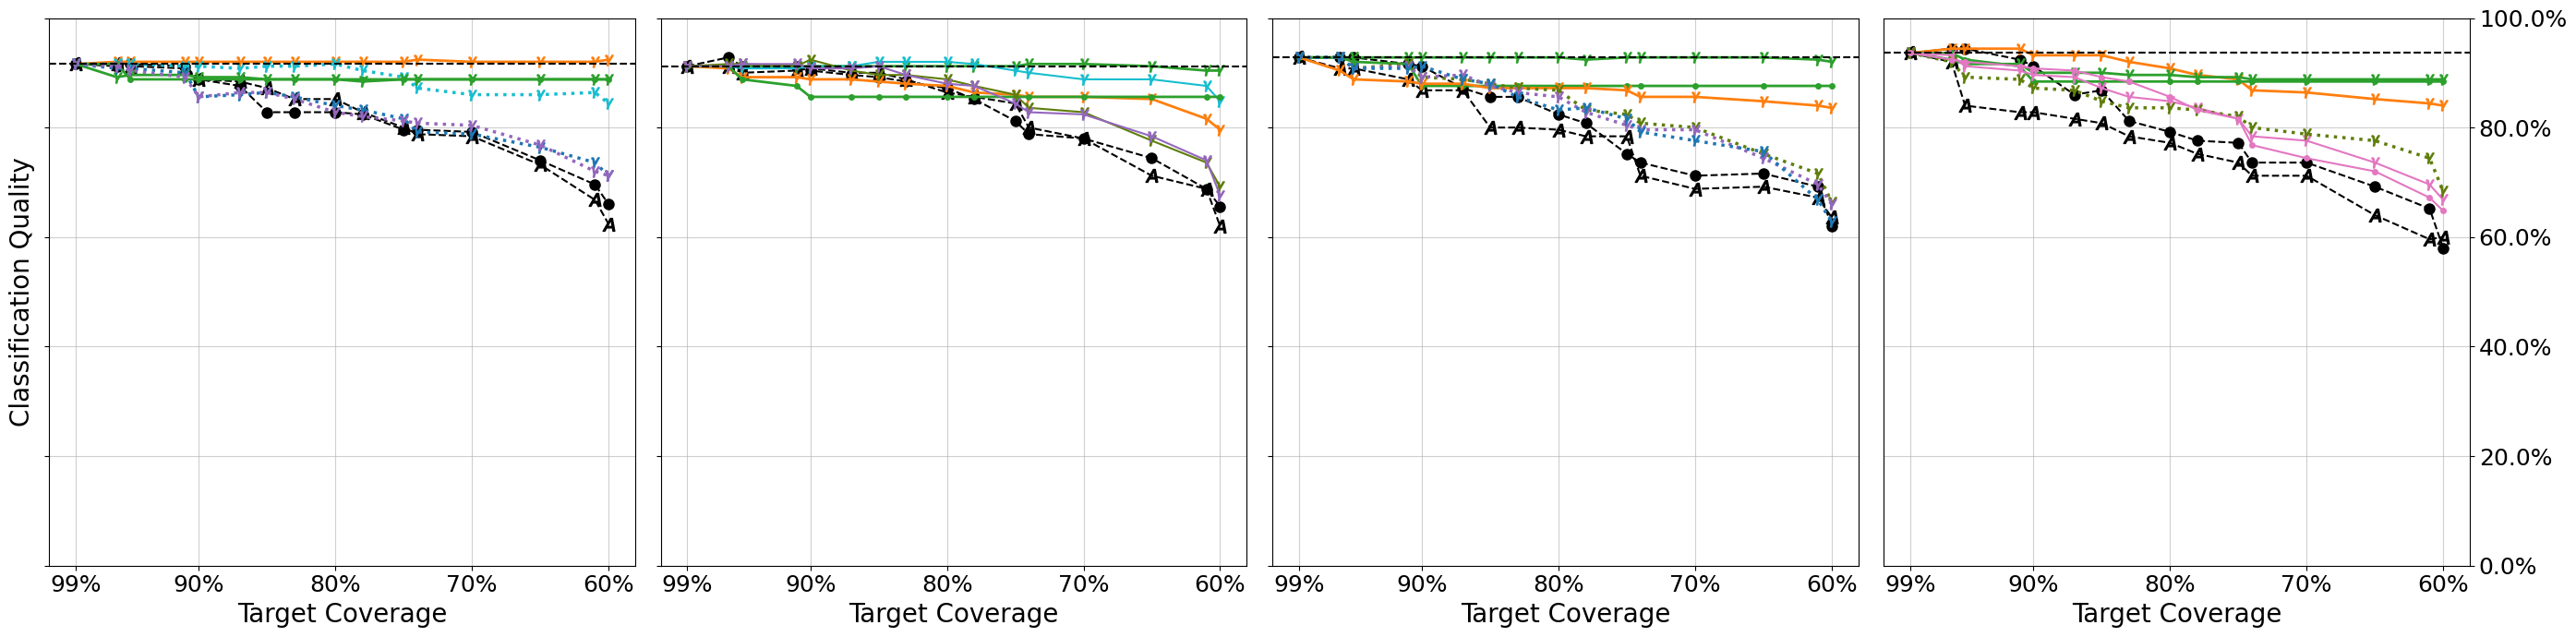

['PlugInRule', 'PlugInRuleAUC', 'LORE - cosine$^{\\gamma}_{max}$', 'LORE - sqeuclidean$^{\\gamma}_{min}$', 'LORE - braycurtis$_{max}$', 'LORE - braycurtis$^{\\gamma}_{max}$', 'LORE - inf$^{\\gamma}_{min}$', 'LORE - l2$^{\\gamma}_{min}$', 'LORE - braycurtis$^{\\gamma}_{max}$', 'LORE - sqeuclidean$^{\\gamma}_{mean}$', 'LORE - cosine$^{\\gamma}_{max}$', 'LORE - braycurtis$_{max}$', 'LORE - l1$^{\\gamma}_{mean}$', 'LORE - l2$^{\\gamma}_{mean}$', 'LORE - braycurtis$^{\\gamma}_{max}$', 'LORE - braycurtis$_{max}$', 'LORE - cosine$^{\\gamma}_{max}$', 'LORE - l1$^{\\gamma}_{min}$', 'LORE - l2$^{\\gamma}_{min}$', 'LORE - inf$^{\\gamma}_{min}$', 'LORE - cosine$^{\\gamma}_{max}$', 'LORE - braycurtis$^{\\gamma}_{max}$', 'LORE - braycurtis$_{max}$', 'LORE - wasserstein$^{\\gamma}_{mean}$', 'LORE - l1$^{\\gamma}_{min}$', 'LORE - wasserstein$_{mean}$']


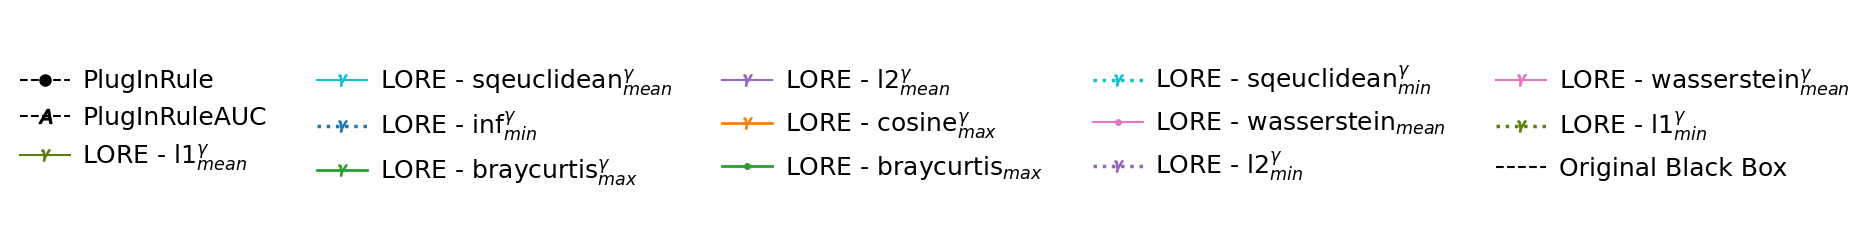

vmax 1.007
minimum 0.905


Visualizing results:   0%|          | 0/4 [00:00<?, ?it/s]

top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_l2_min_gamma_duplicate', 'lore_CFDistRejector_inf_min_gamma_duplicate', 'lore_CFDistRejector_inf_mean_duplicate', 'lore_CFDistRejector_inf_mean_gamma_duplicate', 'lore_CFDistRejector_l2_min_duplicate', 'lore_CFDistRejector_l1_min_gamma_duplicate']
0.905 1.007
top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_l1_min_gamma_duplicate', 'lore_CFDistRejector_l1_min_duplicate', 'lore_CFDistRejector_l2_min_duplicate', 'lore_CFDistRejector_l2_min_gamma_duplicate', 'lore_CFDistRejector_sqeuclidean_min_gamma', 'lore_CFDistRejector_inf_min_gamma_duplicate']
0.905 1.007
top_policies ['lore_PlugInRule', 'lore_PlugInRuleAUC', 'lore_CFDistRejector_sqeuclidean_min_gamma', 'lore_CFDistRejector_l2_min_gamma_duplicate', 'lore_CFDistRejector_inf_min_gamma_duplicate', 'lore_CFDistRejector_l1_min_gamma_duplicate', 'lore_CFDistRejector_l2_min_duplicate', 'lore_CFDistRejector_inf_min_duplicate']
0.905 1.007
t

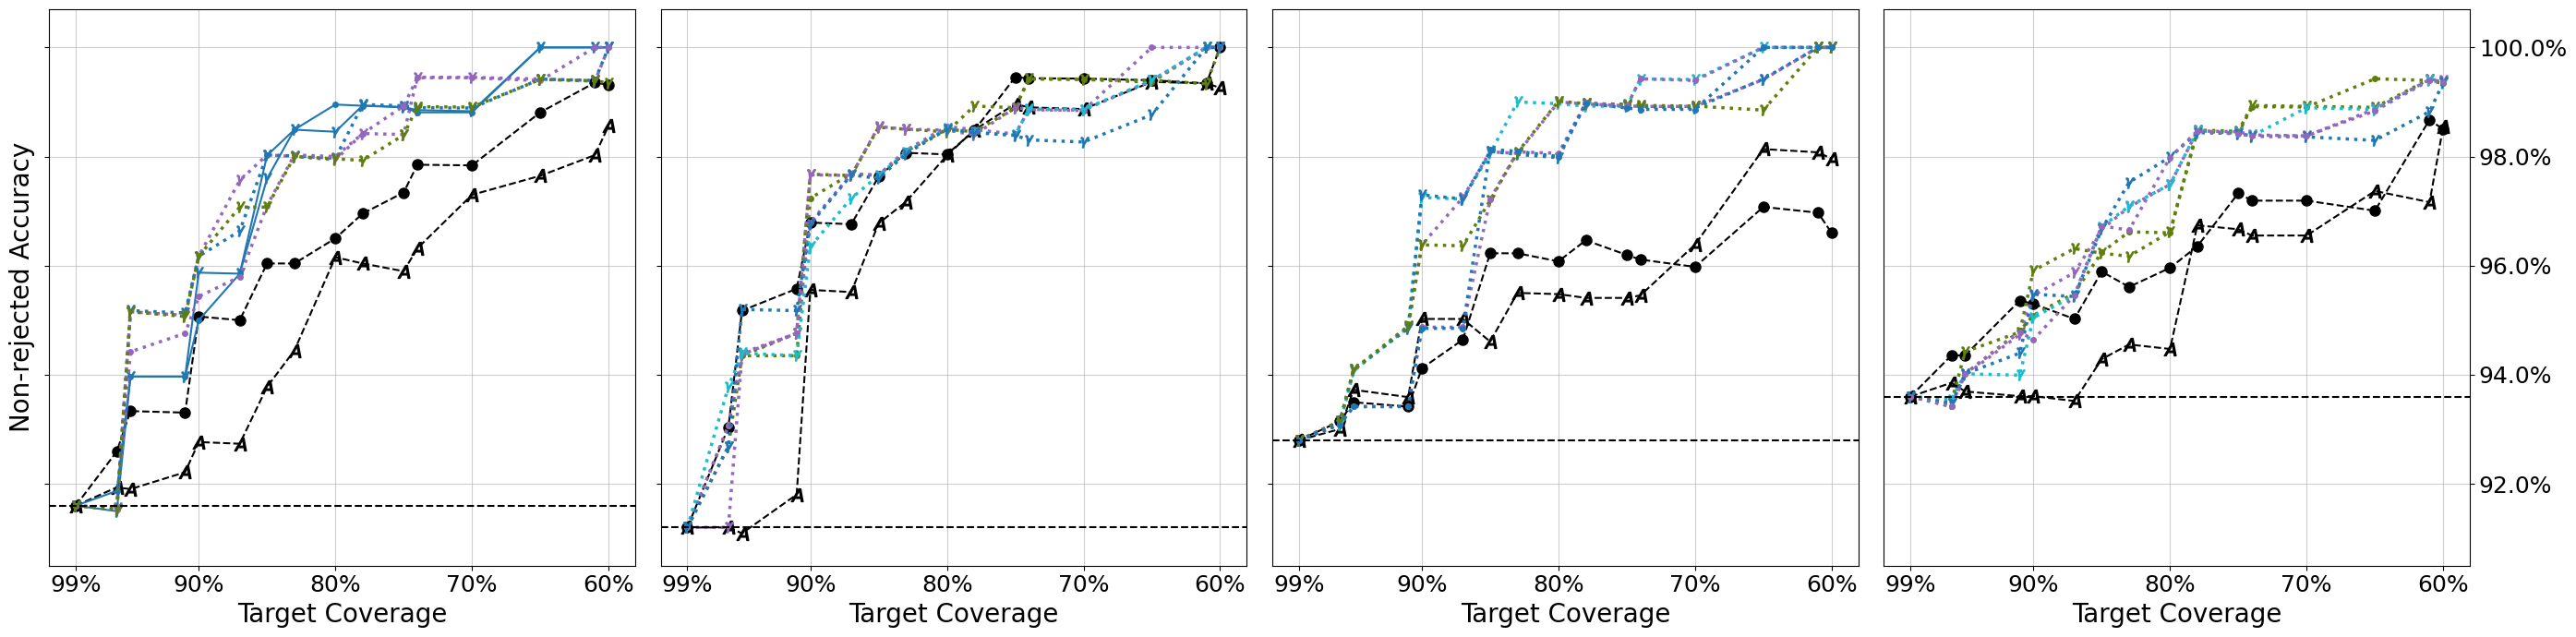

['PlugInRule', 'PlugInRuleAUC', 'LORE - l2$^{\\gamma}_{min}$', 'LORE - inf$^{\\gamma}_{min}$', 'LORE - inf$_{mean}$', 'LORE - inf$^{\\gamma}_{mean}$', 'LORE - l2$_{min}$', 'LORE - l1$^{\\gamma}_{min}$', 'LORE - l1$^{\\gamma}_{min}$', 'LORE - l1$_{min}$', 'LORE - l2$_{min}$', 'LORE - l2$^{\\gamma}_{min}$', 'LORE - sqeuclidean$^{\\gamma}_{min}$', 'LORE - inf$^{\\gamma}_{min}$', 'LORE - sqeuclidean$^{\\gamma}_{min}$', 'LORE - l2$^{\\gamma}_{min}$', 'LORE - inf$^{\\gamma}_{min}$', 'LORE - l1$^{\\gamma}_{min}$', 'LORE - l2$_{min}$', 'LORE - inf$_{min}$', 'LORE - l1$^{\\gamma}_{min}$', 'LORE - l2$^{\\gamma}_{min}$', 'LORE - l1$_{min}$', 'LORE - sqeuclidean$^{\\gamma}_{min}$', 'LORE - inf$^{\\gamma}_{min}$', 'LORE - l2$_{min}$']


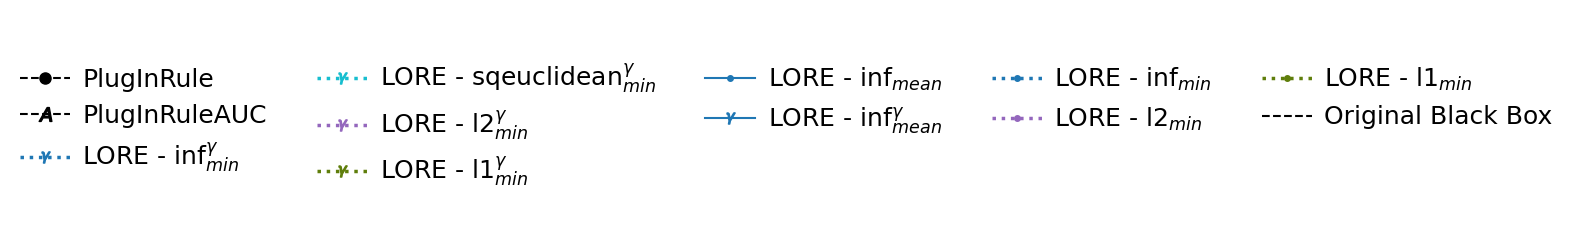

In [55]:

for jjjjj,selective in enumerate([
    "rejection_quality_dict",
    "classification_quality_dict",
    "rejected_by_coverage"
    ]):
    dataframes_ = create_dataframes(models,metric_dicts, info,
                                    selective_metric=selective)
    target_coverages = info["target_coverages"]
    target_coverages_n = info["target_coverages_n"]
    all_original_scores = info["all_original_scores"]
    if jjjjj==2:
        minimum = np.array([all_original_scores[k] for k in all_original_scores.keys()]).min()
        vmax =    0
        for k in models.keys():

            # Get indices of top performing methods by sum across coverages

            fake_auc = dataframes[k].copy().values[:,:target_coverages_n//2].sum(axis=1)
            # sort the fake_auc
            fake_auc = fake_auc.argsort()[::-1]
            # take the top_k rows
            fake_auc = fake_auc[:top_k]
            vmax = max(vmax, dataframes[k].values[fake_auc, :target_coverages_n//2].max())
        minimum-=0.007
        vmax+=0.007
    else:
        minimum = None
        vmax = None
    print("vmax",vmax)
    print("minimum",minimum)
    # create the latex tables
    latex_tables = {k:"" for k in models.keys()}
    big_tables =   {k:"" for k in models.keys()}
    # use the fancy bar from tqdm
    fig, ax = plt.subplots(1, 4, figsize=(7*4, 7))
    ax = ax.flatten()
    plotted_methods = []
    for indx,k in enumerate(tqdm(models.keys(), desc="Visualizing results")):
        # Select top performing methods
        df = dataframes_[k].copy().iloc[:, :target_coverages_n//2]
        
        # it could happen that there is no difference between the methods (some rows are the same and differ only by the index)
        # so we need to drop the duplicates and modify the index of the duplicated rows that are kept by adding a suffix "_duplicate"
        old_index = df.index
        old_df = df.copy()
        # print("Dropping duplicates")
        
        df = df.drop_duplicates()
        for i in old_index:
            if i not in df.index:
                # using the old_df to get the row that is duplicated
                old_row = old_df.loc[i]
                for j in df.index:
                    if j.endswith("_duplicate"):
                        continue
                    if (old_row == old_df.loc[j]).all():
                        if j.endswith("_duplicate"):
                            # I've already found the duplicated row
                            break
                        else:
                            df.loc[j+"_duplicate"] = old_row
                            df = df.drop(j)
                        break
                
        
        # Get indices of top performing methods by sum across coverages
        fake_auc = df.values.sum(axis=1).argsort()[::-1]
        top_policies = list(fake_auc[:top_k])

        # Ensure PlugInRule and PlugInRuleAUC are included
        if 0 not in top_policies:
            top_policies = [0] + top_policies[:-1]
        if 1 not in top_policies:
            top_policies = [1] + top_policies[:-1]
        # now place the PlugInRule and PlugInRuleAUC at the beginning
        top_policies = [0, 1] + [e for e in top_policies if e not in [0, 1]]
        print("top_policies",[cf_method+"_"+e for e in df.index[top_policies]])
        
        top_policies_names = [(fancy_names(cf_method+"_"+fnam)if fnam not in ["PlugInRule", "PlugInRuleAUC"]else fnam) for fnam in df.index[top_policies]]       
        plotted_methods +=   [(fancy_names(cf_method+"_"+fnam)if fnam not in ["PlugInRule", "PlugInRuleAUC"]else fnam) for fnam in df.index[top_policies] if fnam not in plotted_methods]
        column_values = np.concatenate([[0.99],
                                        np.array(target_coverages[:target_coverages_n//2])[((
                                            np.array(target_coverages[:target_coverages_n//2])*100)%10==0)]
                                        ])
        # print("column_values",column_values)
        
        #ax = ax.flatten()
        # Use a basic colormap
        # black and white
        custom_cmap = 'inferno'
        custom_cmap = fplt.parula
        custom_cmap = 'Greys_r'
        
    

        # fig, ax = plt.subplots(1, 1, figsize=(7, 7))
        # # Plot heatmap of top methods
        # plot_heatmap(ax=ax, 
        #             df=df,
        #             top_policies=top_policies,
        #             top_policies_names=top_policies_names,
        #             target_coverages_n=target_coverages_n,
        #             minimum=minimum,
        #             vmax=vmax)
        

        # # Plot line graph of top methods
        plot_line_graph_nb2(ax=ax[indx],
                    df=df,
                    top_policies=top_policies,
                    top_policies_names=top_policies_names,
                    target_coverages=column_values,
                    all_original_scores=all_original_scores,
                    model_name=k,
                    minimumm=minimum,
                    vmaxx=vmax,
                    indx = indx,
                    selective= selective)
        
        # Set titles
        # plt.suptitle(
        #     f"{name_dataset} - Model: {k}",
        #         # {args.method.upper()} {'Latent' if args.latent else ''} - 
        #     fontsize=16
        # )
        '''fig_path = os.path.join(
                "results",
                f"selective_classifier_{name_dataset}_results"+"_"+k+".pdf"
            )
        
        
        
        plt.savefig(fig_path)
        print(f"Saved figure to {fig_path}")  
            # Also save PNG for easy viewing
            #plt.savefig(fig_path.replace(".pdf", ".png"))
        '''
    plt.tight_layout()
    plt.show()
    #plt.close(fig)
    create_legend_file(plotted_methods, "Black Box",dt_name=dt_name)
    plt.show()

In [56]:
dt_name

'toy_dataset'

In [30]:
def create_legend_file(top_policies_names, model_name):
    """Create a standalone legend file with metrics-based coloring."""
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.set_axis_off()  # Hide the axes
    print(top_policies_names)
    
    top_policies_names = list(set(top_policies_names))
    metric_methods = top_policies_names
    # place pluginrule and pluginruleauc at the beginning
    metric_methods = ["PlugInRule", "PlugInRuleAUC"] + [e for e in metric_methods if e not in ["PlugInRule", "PlugInRuleAUC"]] 
    for name in metric_methods:
        style = simplified_plot_styling(name)
        label = name
        ax.plot([], [], 
                    label=label,
                    marker=style['marker'],  # Standard marker
                    ls=style['ls'],
                    color=style['color'],
                    linewidth=style['linewidth'],
                    markersize=style['markersize'])
    ax.plot([], [], label=f"Original {model_name}", color='k', ls='--')
    
    # Create the legend with multiple columns
    legend = ax.legend(loc='center', ncol=3, frameon=False, fontsize=18, 
                      handlelength=2, handletextpad=0.5)
    print(name_dataset)
    # Save just the legend
    fig.savefig(f"results/legend_metrics_{dt_name}.pdf", bbox_inches='tight')
    #plt.close(fig)


In [41]:
for k in models.keys():
    print(dataframes[k][0.99].head())

PlugInRule                                    0.752
PlugInRuleAUC                                 0.752
ils<latent_CFDistRejector_cosine_min          0.752
ils<latent_CFTreeRejector_cosine_min          0.752
ils<latent_CFDistRejector_cosine_min_gamma    0.752
Name: 0.99, dtype: float64
PlugInRule                                    0.744
PlugInRuleAUC                                 0.744
ils<latent_CFDistRejector_cosine_min          0.744
ils<latent_CFTreeRejector_cosine_min          0.744
ils<latent_CFDistRejector_cosine_min_gamma    0.744
Name: 0.99, dtype: float64
PlugInRule                                    0.744
PlugInRuleAUC                                 0.744
ils<latent_CFDistRejector_cosine_min          0.744
ils<latent_CFTreeRejector_cosine_min          0.744
ils<latent_CFDistRejector_cosine_min_gamma    0.744
Name: 0.99, dtype: float64
PlugInRule                                    0.744
PlugInRuleAUC                                 0.744
ils<latent_CFDistRejector_cosine_mi

In [ ]:
all_dataframes = {}
    # Load distance statistics for the cf_methods 
    for cf_method in ["ils","ils_latent","lore"]:#,"dice"]:
        if cf_method == "ils_latent":
            args.latent = True
            cf_method = "ils"
        else:
            args.latent = False
        all_stats, all_stats_test = load_distance_stats(cf_method, args.dataset, args.latent)
        # Check if distances are computed
        for k in models.keys():
            print(k, "computed?", check_res(stats_dict=all_stats, k=k))
            print("\t", "test?", check_res(stats_dict=all_stats_test, k=k))
        
        # Convert lists to arrays
        all_stats = convert_lists_to_arrays(models, all_stats)
        all_stats_test = convert_lists_to_arrays(models, all_stats_test)
        # retain only the L2 and the cosine distance
        #all_stats = {k: {"distances": {m: all_stats[k]["distances"][m] for m in ["l2", "cosine"]}} for k in all_stats.keys()}
        #all_stats_test = {k: {"distances": {m: all_stats_test[k]["distances"][m] for m in ["l2", "cosine"]}} for k in all_stats_test.keys()}

        # Initialize selective classifiers
        rejectors, metric_dicts, info = initialize_rejectors(models, splits)
    
        # Calibrate basic rejectors
        rejectors = calibrate_basic_rejectors(models, rejectors, splits, all_stats, all_stats_test, info)
    
        rejectors = calibrate_distance_rejectors(models, rejectors, splits, all_stats, all_stats_test, info)
        

        # Evaluate all rejectors
        metric_dicts = evaluate_rejectors(models, rejectors, splits, metric_dicts, info)
    
        # Create dataframes for visualization
        dataframes = create_dataframes(models, metric_dicts, info)
        print(type(dataframes["mlp"]), dataframes["mlp"].columns)
        # dataframes is a dict of dataframes, the key is the model, the value the dataframe
        if cf_method == "ils":
            if args.latent:
                cf_method = "ils<latent"
        for km in dataframes.keys():
            # remove the name CFDistRejector from the indexes and replace it by the cf_method
            dataframes[km].index = [(f"{cf_method}_{col}" if col not in ["PlugInRule", "PlugInRuleAUC"] else col) for col in dataframes[km].index]
        for km in dataframes.keys():
            if km not in all_dataframes.keys():
                all_dataframes[km] = dataframes[km]
            else:
                # drop the raws relatively to the PlugInRule and PlugInRuleAUC
                dataframes[km] = dataframes[km].drop(["PlugInRule", "PlugInRuleAUC"], axis=0)
                all_dataframes[km] = pd.concat([all_dataframes[km], dataframes[km]], axis=0)

## Add Statistical tests to the Selective classifiers
